## Bisecting K-Means

In [1]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ML").master("local[*]").getOrCreate()
spark.conf.set("spark.sql.ansi.enabled", False)
data_dir = "e-shop clothing 2008.csv"

In the first experiments we will ignore the order of logs inside individual sessions, we will one-hot categorical variables, we will also drop country column for now as most of logs are coming from Poland, year contains only one value, month contains only four. Day number will be Min-Max scaled and Price will be whitened, after we will apply PCA

In [2]:
df = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df = df.drop("year", "month", "order", "session ID", "country")
df.show(5)

+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|day|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|  1|                     1|                    A13|     1|       5|                1|   28|      2|   1|
|  1|                     1|                    A16|     1|       6|                1|   33|      2|   1|
|  1|                     2|                     B4|    10|       2|                1|   52|      1|   1|
|  1|                     2|                    B17|     6|       6|                2|   38|      2|   1|
|  1|                     2|                     B8|     4|       3|                2|   52|      1|   1|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
only showing top 5 rows



In [3]:
from pyspark.ml.feature import OneHotEncoder, StandardScaler, VectorAssembler, MinMaxScaler, StringIndexer, PCA
from pyspark.ml import Pipeline
from pyspark.sql import DataFrame

#split clothing model strings into letter and number
string_col = "page 2 (clothing model)"
df1 = df.withColumn("model_letter", F.substring(string_col, 1, 1)).withColumn("model_number", F.substring(string_col, 2, 3)).drop(string_col)
df1 = df1.withColumnRenamed(df.columns[1], "main_category")

#prepare column names
numeric_cols = ["day", "price"]
string_cols = ["model_letter", "model_number"]
binary_cols = ["price 2", "model photography"]
si_output = [col + "_id" for col in string_cols]
binary_output = [col + "_id" for col in binary_cols]
categorical_cols = df1.columns
categorical_cols = [col for col in categorical_cols if col not in numeric_cols + string_cols + binary_cols]
categorical_cols += si_output
final_cols = [col+ "_enc"  for col in categorical_cols] + [col + "_s" for col in numeric_cols] + binary_output

#first encode letters, and additionally convert binary to 0, 1 index (1,2 now)
si = StringIndexer(inputCols=string_cols + binary_cols, outputCols=si_output + binary_output)

#onehot categorical columns
ohe = OneHotEncoder(inputCols=categorical_cols, outputCols=[col + "_enc" for col in categorical_cols])

#va's for continous, vectorize continous
va_1 = VectorAssembler(inputCols=["price"], outputCol="price_v")
va_2 = VectorAssembler(inputCols=["day"], outputCol="day_v")
vas = [va_1, va_2]

# scalers 
ss = StandardScaler(inputCol = "price_v", outputCol="price_s")
mm = MinMaxScaler(inputCol= "day_v", outputCol="day_s")

#Final vector 
va_final = VectorAssembler(inputCols=final_cols, outputCol="vector")

#Reduce
pca = PCA(k = 30, inputCol="vector", outputCol="reduced")

stages = [*vas, si, ohe, ss, mm, va_final, pca]
pipe = Pipeline(stages = stages)

## Evaluation

Explained Variance: 0.9015153358302594


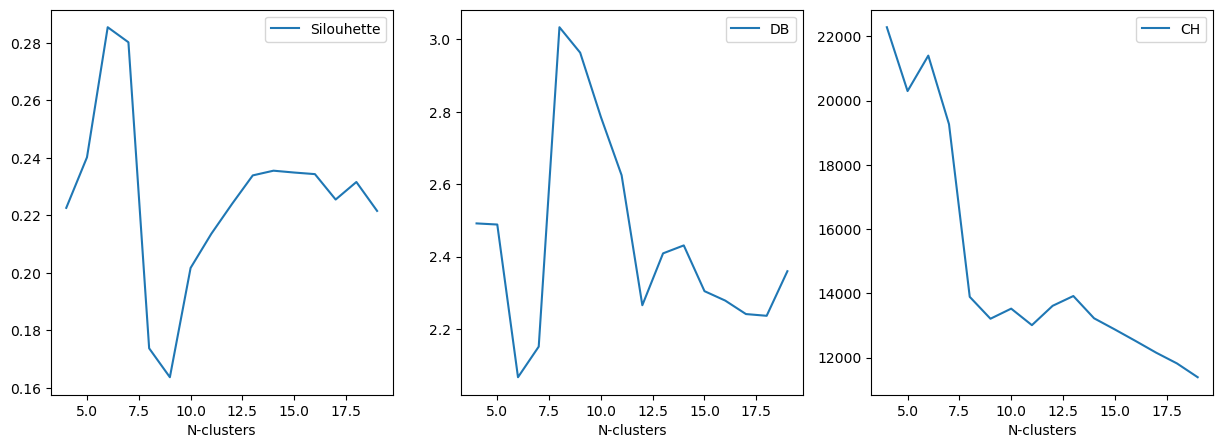

In [4]:
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def evaluate_kmeans(vector_db: DataFrame, pipeline: Pipeline, N_K: list[int], features_col: str = "reduced", prediction_col: str = "pred"):
    #since dataset is small we can straight evaluate also DB and CH scores using sklearn, by converting our feature vector into numpy array,
    #bigger dataset requires subsampling or implemenation of scoring

    fitted = pipeline.fit(vector_db)
    X = fitted.transform(vector_db)
    print("Explained Variance:", sum(fitted.stages[-1].explainedVariance))
    x = X.select(vector_to_array(X[features_col]).alias("vector")).toPandas()
    x = np.array(x["vector"].to_list())

    results = {"N_K": [], "silouhette" : [], "davies_bouldin": [], "calinski_harabasz": []}
    ce = ClusteringEvaluator(predictionCol=prediction_col, featuresCol=features_col)

    for K in N_K:
        model = BisectingKMeans(k = K, maxIter=30, featuresCol=features_col, predictionCol=prediction_col, seed=42).fit(X)
        preds = model.transform(X)
        y = preds.select(prediction_col).toPandas()[prediction_col]
        results["silouhette"].append(ce.evaluate(preds))
        results["davies_bouldin"].append(davies_bouldin_score(x, y))
        results["calinski_harabasz"].append(calinski_harabasz_score(x, y))
        results["N_K"].append(K)

    fig, ax = plt.subplots(1, 3, figsize = (15, 5), sharex=True)
    ax[0].plot(results["N_K"], results["silouhette"], label = "Silouhette")
    ax[1].plot(results["N_K"], results["davies_bouldin"], label = "DB")
    ax[2].plot(results["N_K"], results["calinski_harabasz"], label = "CH")
    for ax_ in ax:
        ax_.legend()
        ax_.set_xlabel("N-clusters")
    plt.show()
    return results

results = evaluate_kmeans(df1, pipe, range(4, 20))

Explained Variance: 0.838701155445923


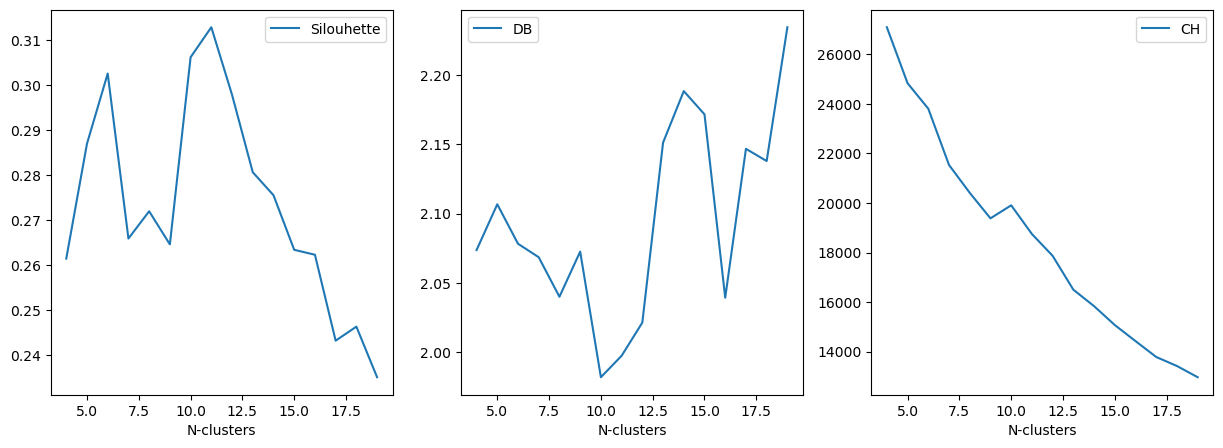

In [5]:
pca.setK(20)
results = evaluate_kmeans(df1, pipe, range(4, 20))

Explained Variance: 0.78576714680193


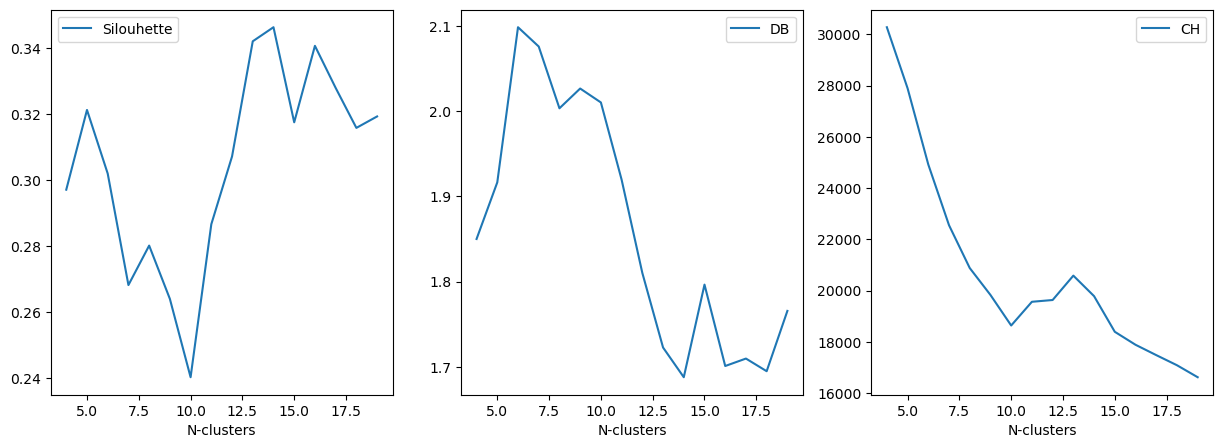

In [6]:
pca.setK(15)
results = evaluate_kmeans(df1, pipe, range(4, 20))